In [3]:
import os
import numpy as np
import cv2
from PIL import Image
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamPredictor
# Load model
sam_checkpoint = "/Users/dylanjitton/Documents/project_plantDisease/ImagePlantSegmentator/sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
predictor = SamPredictor(sam)

def mask_and_segment_hyper(folder_path, output_name, sam_predictor):
    # Find files
    png_file = None
    dat_file = None
    hdr_file = None
    for f in os.listdir(folder_path):
        if f.endswith('.png'):
            png_file = os.path.join(folder_path, f)
        elif f.endswith('.dat'):
            dat_file = os.path.join(folder_path, f)
        elif f.endswith('.hdr'):
            hdr_file = os.path.join(folder_path, f)
    if not (png_file and dat_file and hdr_file):
        print("❌ Missing one or more required files (.png, .dat, .hdr) in", folder_path)
        return

    # Load hyperspectral cube and get shape
    img = envi.open(hdr_file, dat_file)
    cube = img.load()  # shape: (lines, samples, bands)
    print(cube.shape)
    cube_height, cube_width = cube.shape[0], cube.shape[1]

    # Load PNG and resize to match cube shape (if needed)
    image = cv2.imread(png_file)
    if image is None:
        print(f"❌ Could not load image: {png_file}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if image.shape[0] != cube_height or image.shape[1] != cube_width:
        image = cv2.resize(image, (cube_width, cube_height), interpolation=cv2.INTER_AREA)

    # Generate mask with SAM on the whole image
    sam_predictor.set_image(image)
    input_point = np.array([[cube_width // 2, cube_height // 2]])  # Center point
    input_label = np.array([1])
    masks, scores, logits = sam_predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,
    )
    # Heuristic mask selection
    h, w = masks[0].shape
    image_area = h * w
    selected_mask = None
    best_score = -1
    for i, mask in enumerate(masks):
        mask_area = np.sum(mask)
        proportion = mask_area / image_area
        if 0.01 < proportion < 0.9 and scores[i] > best_score:
            best_score = scores[i]
            selected_mask = mask
        plt.figure()
        plt.imshow(image)
        plt.imshow(mask, alpha=0.5)
        plt.title(f"Mask {i+1} - Score: {scores[i]:.2f}, Proportion: {proportion:.2f}")
        plt.axis("off")
        plt.show()
    if selected_mask is None:
        print("⚠️ No suitable SAM mask found, aborting hyperspectral masking.")
        return

    # Save mask PNG for reference
    mask_uint8 = (selected_mask * 255).astype(np.uint8)
    masked_image = image.copy()
    masked_image[selected_mask == 0] = 0
    rgba_image = np.dstack((masked_image, mask_uint8))
    mask_png_path = os.path.join(folder_path, f"{output_name}_mask.png")
    Image.fromarray(rgba_image).save(mask_png_path)
    print(f"✅ Saved mask PNG: {mask_png_path}")

     # Check orientation
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("PNG (for mask)")
    plt.subplot(1,2,2)
    plt.imshow(cube[:,:,0], cmap='gray')
    plt.title("Hyperspectral Band 0")
    plt.show()

    # If mask appears rotated/transposed, fix it:
    # Try one of these (uncomment one at a time to test):
    selected_mask = np.transpose(selected_mask)
    selected_mask = np.flipud(selected_mask)
    # selected_mask = np.fliplr(selected_mask)

    # Apply mask to hyperspectral cube
    mask_3d = np.repeat(selected_mask[:, :, np.newaxis], cube.shape[2], axis=2)
    masked_cube = np.where(mask_3d, cube, 0)

    # # Apply mask to hyperspectral cube
    # mask_3d = np.repeat(selected_mask[:, :, np.newaxis], cube.shape[2], axis=2)
    # masked_cube = np.where(mask_3d, cube, 0)

    # Save new ENVI file
    new_hdr = os.path.join(folder_path, f"{output_name}_masked.hdr")
    new_dat = os.path.join(folder_path, f"{output_name}_masked.dat")
    # Load original metadata
    original_meta = img.metadata.copy()

    # Adjust spatial shape (the mask doesn't change shape)
    original_meta['lines'] = masked_cube.shape[0]
    original_meta['samples'] = masked_cube.shape[1]
    original_meta['bands'] = masked_cube.shape[2]

    # Update file info for the new ENVI file
    original_meta['file type'] = 'ENVI Standard'
    original_meta['description'] = '{Masked leaf hyperspectral cube}'
    original_meta['data type'] = 4
    original_meta['interleave'] = 'bil'
    original_meta['byte order'] = 0
    original_meta['header offset'] = 0

    # Remove irrelevant keys that Spectral can’t serialize safely
    for bad_key in ['history', 'data ignore value']:
        original_meta.pop(bad_key, None)

    # Save masked cube preserving wavelengths and sensor info
    envi.save_image(
        new_hdr,
        masked_cube,
        dtype=np.float32,
        interleave='bil',
        ext='.dat',
        force=True,
        metadata=original_meta
    )

    print(f"✅ Saved masked hyperspectral cube with preserved metadata: {new_hdr}")

    # envi.save_image(new_hdr, masked_cube, dtype=np.float32, interleave='bil',ext='.dat',force=True)
    # print(f"✅ Saved masked hyperspectral cube: {new_hdr}, {new_dat}")

    # Optional: visualize a band
    plt.figure()
    plt.imshow(masked_cube[:, :, 0], cmap='gray')
    plt.title('Masked Band 0')
    plt.show()

    # --- Extract leaf pixels ---
    # Get only the spectral data inside the cutout (mask)
    mask_flat = selected_mask.flatten()
    cube_flat = cube.reshape(-1, cube.shape[2])  # shape: (height*width, bands)
    leaf_pixels = cube_flat[mask_flat == 1]      # shape: (num_leaf_pixels, bands)
    print(f"✅ Extracted leaf pixels: {leaf_pixels.shape[0]} pixels, {leaf_pixels.shape[1]} bands")

    # Optionally save leaf pixels to .npy
    np.save(os.path.join(folder_path, f"{output_name}_leaf_pixels.npy"), leaf_pixels)
    print(f"✅ Saved leaf pixel spectra to {output_name}_leaf_pixels.npy")

    # Optionally save to CSV (first 10 bands for preview)
    np.savetxt(os.path.join(folder_path, f"{output_name}_leaf_pixels.csv"), leaf_pixels[:, :10], delimiter=",")
    print(f"✅ Saved leaf pixel spectra (first 10 bands) to {output_name}_leaf_pixels.csv")

/Users/dylanjitton/anaconda3/lib/python3.11/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


(512, 512, 204)


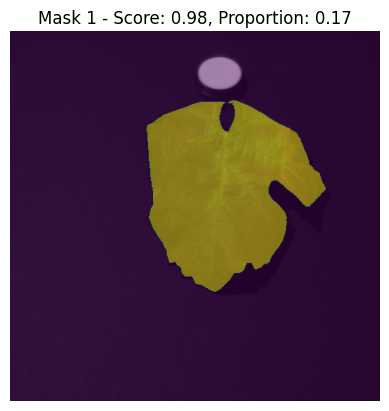

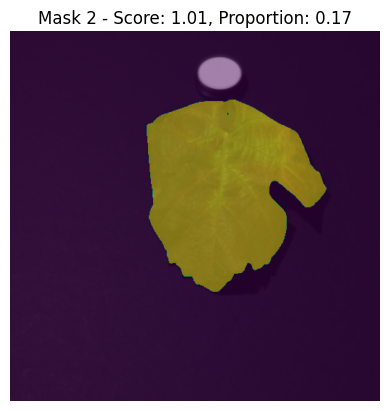

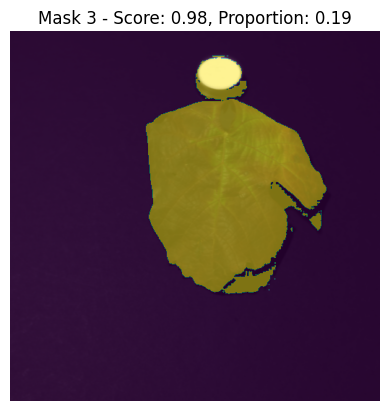

✅ Saved mask PNG: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_mask.png


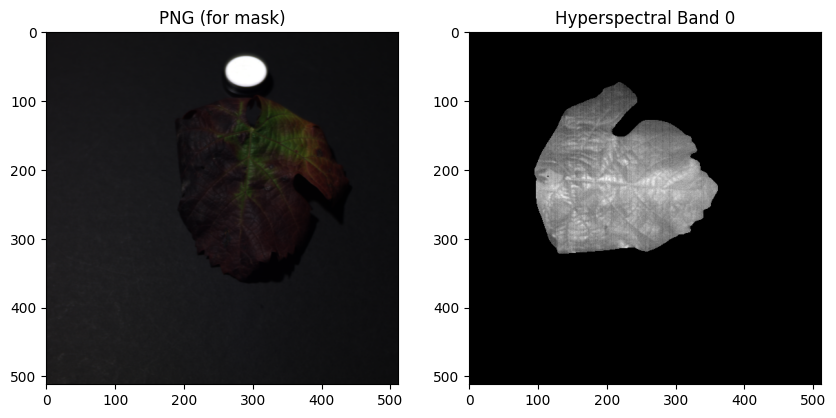

✅ Saved masked hyperspectral cube with preserved metadata: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.hdr


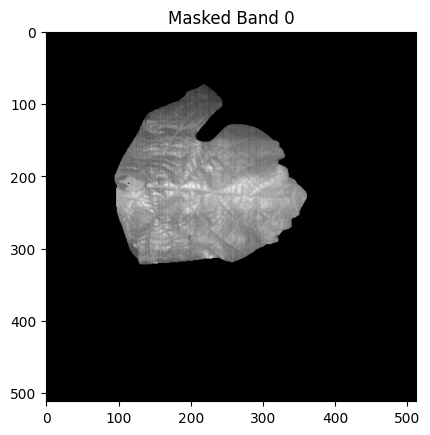

✅ Extracted leaf pixels: 44502 pixels, 204 bands
✅ Saved leaf pixel spectra to leaf_segmented_leaf_pixels.npy
✅ Saved leaf pixel spectra (first 10 bands) to leaf_segmented_leaf_pixels.csv


In [56]:
mask_and_segment_hyper(
    '/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results',
    'leaf_segmented',
    predictor  # Your initialized SamPredictor

)

In [4]:
import os
import numpy as np
import spectral.io.envi as envi

def downsample_envi_cube(
    input_hdr,
    input_dat=None,
    output_hdr=None,
    kernel=4,
    stride=None,
    dtype=np.float32,
    interleave='bil',
    ext='.dat',
    pad_value=0.0,
    overwrite=False
):
    """
    Downsample an ENVI hyperspectral cube by spatial block-averaging (uniform kernel).
    Preserves original metadata including wavelengths and sensor info.
    """
    if stride is None:
        stride = kernel
    
    # Open input ENVI file
    img = envi.open(input_hdr, input_dat) if input_dat else envi.open(input_hdr)
    cube = img.load()
    lines, samples, bands = cube.shape
    print(f"Input cube shape: lines={lines}, samples={samples}, bands={bands}")
    
    # Compute padded output dimensions (for stride == kernel)
    if stride == kernel:
        pad_y = (kernel - (lines % kernel)) % kernel
        pad_x = (kernel - (samples % kernel)) % kernel
        if pad_y or pad_x:
            print(f"Padding input: pad_y={pad_y}, pad_x={pad_x}")
        padded_lines = lines + pad_y
        padded_samples = samples + pad_x
        out_lines = padded_lines // kernel
        out_samples = padded_samples // kernel
        out_cube = np.zeros((out_lines, out_samples, bands), dtype=dtype)
        
        for b in range(bands):
            band = cube[:, :, b].astype(np.float32)
            if pad_y or pad_x:
                band = np.pad(band, ((0, pad_y), (0, pad_x)), constant_values=pad_value)
            band_reshaped = band.reshape(out_lines, kernel, out_samples, kernel)
            band_down = band_reshaped.mean(axis=(1, 3))
            out_cube[:, :, b] = band_down
            if (b + 1) % 20 == 0 or b == bands - 1:
                print(f"Processed band {b + 1}/{bands}")
    else:
        # General stride case
        out_lines = (lines - kernel) // stride + 1
        out_samples = (samples - kernel) // stride + 1
        out_cube = np.zeros((out_lines, out_samples, bands), dtype=dtype)
        
        for b in range(bands):
            band = cube[:, :, b].astype(np.float32)
            for i, y in enumerate(range(0, lines - kernel + 1, stride)):
                for j, x in enumerate(range(0, samples - kernel + 1, stride)):
                    out_cube[i, j, b] = band[y:y + kernel, x:x + kernel].mean()
            if (b + 1) % 20 == 0 or b == bands - 1:
                print(f"Processed band {b + 1}/{bands}")
    
    # --- Output handling ---
    base = os.path.splitext(os.path.basename(input_hdr))[0]
    if output_hdr is None:
        output_hdr = os.path.join(os.path.dirname(input_hdr), f"{base}_ds{kernel}.hdr")
    out_dat = os.path.splitext(output_hdr)[0] + ext
    
    if not overwrite and (os.path.exists(output_hdr) or os.path.exists(out_dat)):
        raise FileExistsError("Output files already exist. Set overwrite=True to replace.")
    
    # Copy original metadata and update spatial dimensions
    original_meta = img.metadata.copy()
    
    # Update required fields for downsampled cube
    original_meta['lines'] = out_cube.shape[0]
    original_meta['samples'] = out_cube.shape[1]
    original_meta['bands'] = out_cube.shape[2]
    
    # Update file info
    original_meta['file type'] = 'ENVI Standard'
    original_meta['description'] = f'{{Downsampled ENVI file (kernel={kernel})}}'
    original_meta['data type'] = 4  # float32
    original_meta['interleave'] = interleave
    original_meta['byte order'] = 0
    original_meta['header offset'] = 0
    
    # Remove problematic keys that Spectral can't serialize
    for bad_key in ['history', 'data ignore value']:
        original_meta.pop(bad_key, None)
    
    print(f"Saving downsampled cube to: {output_hdr} (binary ext: {ext})")
    print(f"Preserved metadata keys: {list(original_meta.keys())}")
    
    envi.save_image(
        output_hdr,
        out_cube,
        dtype=dtype,
        interleave=interleave,
        ext=ext,
        force=True,
        metadata=original_meta
    )
    
    print(f"✅ Saved downsampled cube with preserved metadata")
    return output_hdr, out_dat


In [62]:
input_hdr = "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.hdr"
input_dat = "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.dat"
# input_dat can be omitted if header points to the data file with expected name
out_hdr, out_dat = downsample_envi_cube(input_hdr, input_dat, kernel=4, stride=None, overwrite=True)
print("Created:", out_hdr, out_dat)


Input cube shape: lines=512, samples=512, bands=204
Processed band 20/204
Processed band 40/204
Processed band 60/204
Processed band 80/204
Processed band 100/204
Processed band 120/204
Processed band 140/204
Processed band 160/204
Processed band 180/204
Processed band 200/204
Processed band 204/204
Saving downsampled cube to: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_ds4.hdr (binary ext: .dat)
Preserved metadata keys: ['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength']
✅ Saved downsampled cube with preserved metadata
Created: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_ds4.hdr /Users/dylanjitton/Documents/project_plantDisease/dataverse_fi

In [5]:
def trim_wavelength_range(
    input_hdr,
    input_dat=None,
    output_hdr=None,
    min_wavelength=450,
    max_wavelength=950,
    dtype=np.float32,
    interleave='bil',
    ext='.dat',
    overwrite=False
):
    """
    Trim an ENVI hyperspectral cube to a specific wavelength range.
    
    Parameters:
    -----------
    input_hdr : str
        Path to input .hdr file
    input_dat : str, optional
        Path to input .dat file (if None, inferred from .hdr)
    output_hdr : str, optional
        Path to output .hdr file (if None, auto-generated)
    min_wavelength : float
        Minimum wavelength to keep (nm)
    max_wavelength : float
        Maximum wavelength to keep (nm)
    """
    
    # Open input ENVI file
    img = envi.open(input_hdr, input_dat) if input_dat else envi.open(input_hdr)
    cube = img.load()
    lines, samples, bands = cube.shape
    print(f"Input cube shape: lines={lines}, samples={samples}, bands={bands}")
    
    # Get wavelength information
    metadata = img.metadata
    if 'wavelength' not in metadata:
        raise ValueError("No wavelength information found in metadata!")
    
    wavelengths = np.array([float(w) for w in metadata['wavelength']])
    print(f"Original wavelength range: {wavelengths[0]:.2f} - {wavelengths[-1]:.2f} nm")
    
    # Find bands within the desired range
    band_indices = np.where((wavelengths >= min_wavelength) & (wavelengths <= max_wavelength))[0]
    
    if len(band_indices) == 0:
        raise ValueError(f"No bands found in range {min_wavelength}-{max_wavelength} nm")
    
    print(f"Selected {len(band_indices)} bands from index {band_indices[0]} to {band_indices[-1]}")
    print(f"Trimmed wavelength range: {wavelengths[band_indices[0]]:.2f} - {wavelengths[band_indices[-1]]:.2f} nm")
    
    # Extract the selected bands
    trimmed_cube = cube[:, :, band_indices]
    trimmed_wavelengths = wavelengths[band_indices]
    
    # Output handling
    base = os.path.splitext(os.path.basename(input_hdr))[0]
    if output_hdr is None:
        output_hdr = os.path.join(
            os.path.dirname(input_hdr), 
            f"{base}_trim{int(min_wavelength)}-{int(max_wavelength)}.hdr"
        )
    out_dat = os.path.splitext(output_hdr)[0] + ext
    
    if not overwrite and (os.path.exists(output_hdr) or os.path.exists(out_dat)):
        raise FileExistsError("Output files already exist. Set overwrite=True to replace.")
    
    # Copy and update metadata
    original_meta = metadata.copy()
    
    # Update dimensions
    original_meta['lines'] = trimmed_cube.shape[0]
    original_meta['samples'] = trimmed_cube.shape[1]
    original_meta['bands'] = trimmed_cube.shape[2]
    
    # Update wavelength information
    original_meta['wavelength'] = [str(w) for w in trimmed_wavelengths]
    
    # If wavelength units exist, keep them
    if 'wavelength units' in original_meta:
        print(f"Wavelength units: {original_meta['wavelength units']}")
    
    # Update file info
    original_meta['file type'] = 'ENVI Standard'
    original_meta['description'] = f'{{Wavelength-trimmed cube: {min_wavelength}-{max_wavelength} nm}}'
    original_meta['data type'] = 4  # float32
    original_meta['interleave'] = interleave
    original_meta['byte order'] = 0
    original_meta['header offset'] = 0
    
    # Remove problematic keys
    for bad_key in ['history', 'data ignore value']:
        original_meta.pop(bad_key, None)
    
    print(f"Saving trimmed cube to: {output_hdr}")
    
    envi.save_image(
        output_hdr,
        trimmed_cube,
        dtype=dtype,
        interleave=interleave,
        ext=ext,
        force=True,
        metadata=original_meta
    )
    
    print(f"✅ Saved trimmed cube with {trimmed_cube.shape[2]} bands")
    print(f"✅ Wavelength metadata updated")
    return output_hdr, out_dat

In [64]:
input_hdr = "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.hdr"
trim_wavelength_range(
        input_hdr,
        min_wavelength=450,
        max_wavelength=950,
        overwrite=True
    )

Input cube shape: lines=512, samples=512, bands=204
Original wavelength range: 397.32 - 1003.58 nm
Selected 167 bands from index 19 to 185
Trimmed wavelength range: 452.25 - 948.10 nm
Saving trimmed cube to: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-950.hdr
✅ Saved trimmed cube with 167 bands
✅ Wavelength metadata updated


('/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-950.hdr',
 '/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-950.dat')

# Unet
Autoencoder specialized for segmentation

# MSE
la diferencias entre ver segm.y normal, usar metrica para ver cual es mas efectiva

In [6]:
input_hdr = "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.hdr"
trim_wavelength_range(
        input_hdr,
        min_wavelength=450,
        max_wavelength=1000,
        overwrite=True
    )

Input cube shape: lines=512, samples=512, bands=204
Original wavelength range: 397.32 - 1003.58 nm
Selected 183 bands from index 19 to 201
Trimmed wavelength range: 452.25 - 997.40 nm
Saving trimmed cube to: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-1000.hdr
✅ Saved trimmed cube with 183 bands
✅ Wavelength metadata updated


('/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-1000.hdr',
 '/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-1000.dat')

In [7]:
input_hdr = "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.hdr"
trim_wavelength_range(
        input_hdr,
        min_wavelength=400,
        max_wavelength=950,
        overwrite=True
    )

Input cube shape: lines=512, samples=512, bands=204
Original wavelength range: 397.32 - 1003.58 nm
Selected 185 bands from index 1 to 185
Trimmed wavelength range: 400.20 - 948.10 nm
Saving trimmed cube to: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim400-950.hdr
✅ Saved trimmed cube with 185 bands
✅ Wavelength metadata updated


('/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim400-950.hdr',
 '/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim400-950.dat')

In [8]:
input_hdr = "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.hdr"
trim_wavelength_range(
        input_hdr,
        min_wavelength=420,
        max_wavelength=950,
        overwrite=True
    )

Input cube shape: lines=512, samples=512, bands=204
Original wavelength range: 397.32 - 1003.58 nm
Selected 178 bands from index 8 to 185
Trimmed wavelength range: 420.40 - 948.10 nm
Saving trimmed cube to: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim420-950.hdr
✅ Saved trimmed cube with 178 bands
✅ Wavelength metadata updated


('/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim420-950.hdr',
 '/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim420-950.dat')

In [10]:
input_hdr = "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.hdr"
trim_wavelength_range(
        input_hdr,
        min_wavelength=500,
        max_wavelength=800,
        overwrite=True
    )

Input cube shape: lines=512, samples=512, bands=204
Original wavelength range: 397.32 - 1003.58 nm
Selected 101 bands from index 36 to 136
Trimmed wavelength range: 501.72 - 798.77 nm
Saving trimmed cube to: /Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim500-800.hdr
✅ Saved trimmed cube with 101 bands
✅ Wavelength metadata updated


('/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim500-800.hdr',
 '/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim500-800.dat')